## Feature Engineering

### Handling MIssing Valiues

In [191]:
import seaborn as sns

In [192]:
titanic_dataset = sns.load_dataset("titanic")
titanic_dataset.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [193]:
titanic_dataset.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [194]:
titanic_dataset.shape

(891, 15)

In [195]:
titanic_dataset.dropna().shape

(182, 15)

In [196]:
titanic_dataset.dropna(axis=1).shape

(891, 11)

In [197]:
titanic_dataset.drop(columns=["deck"]).shape


(891, 14)

In [198]:
titanic_dataset.drop(columns=["deck"]).dropna().shape


(712, 14)

### Imputation

#### Mean, Mode, Median

In [199]:
# Mean Imputation
titanic_dataset.isnull().sum()


survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

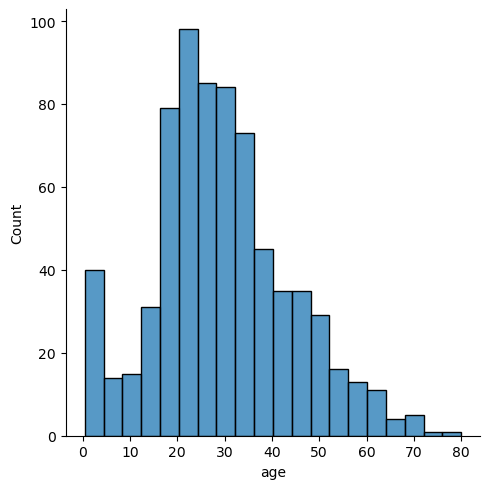

In [200]:
sns.displot(titanic_dataset["age"])

<Axes: xlabel='age', ylabel='Count'>

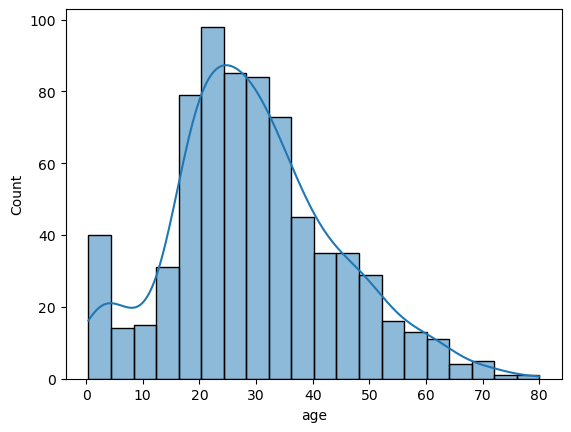

In [201]:
sns.histplot(titanic_dataset["age"], kde=True)


In [202]:
titanic_dataset["age_mean_imputation"] = titanic_dataset["age"].fillna(titanic_dataset["age"].mean())
titanic_dataset[["age_mean_imputation", "age"]]

,age_mean_imputation,age
0,22.000000,22.0
1,38.000000,38.0
2,26.000000,26.0
3,35.000000,35.0
4,35.000000,35.0
...,...,...
886,27.000000,27.0
887,19.000000,19.0
888,29.699118,NaN
889,26.000000,26.0


In [203]:
titanic_dataset.isnull().sum()

survived                 0
pclass                   0
sex                      0
age                    177
sibsp                    0
parch                    0
fare                     0
embarked                 2
class                    0
who                      0
adult_male               0
deck                   688
embark_town              2
alive                    0
alone                    0
age_mean_imputation      0
dtype: int64

<Axes: xlabel='deck', ylabel='Count'>

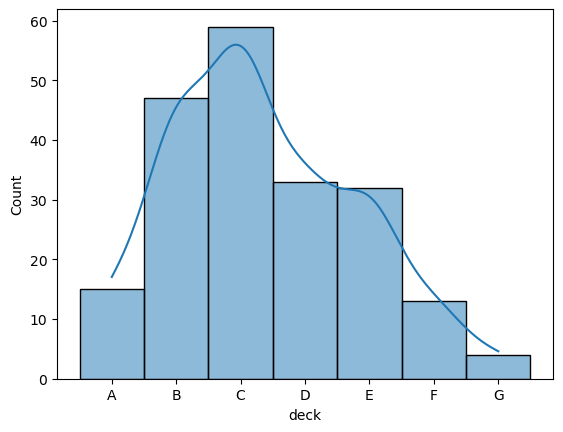

In [204]:
sns.histplot(titanic_dataset["deck"], kde=True)

In [205]:
titanic_dataset.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone,age_mean_imputation
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False,22.0
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False,38.0
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True,26.0
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False,35.0
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True,35.0


In [206]:
titanic_dataset["age_median_imputation"] = titanic_dataset["age"].fillna(titanic_dataset["age"].median())

In [207]:
titanic_dataset.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone,age_mean_imputation,age_median_imputation
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False,22.0,22.0
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False,38.0,38.0
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True,26.0,26.0
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False,35.0,35.0
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True,35.0,35.0


In [208]:
titanic_dataset["embarked"].mode()

0    S
Name: embarked, dtype: object

In [209]:
titanic_dataset[titanic_dataset["embarked"].isnull()]


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone,age_mean_imputation,age_median_imputation
61,1,1,female,38.0,0,0,80.0,NaN,First,woman,False,B,NaN,yes,True,38.0,38.0
829,1,1,female,62.0,0,0,80.0,NaN,First,woman,False,B,NaN,yes,True,62.0,62.0


In [210]:
titanic_dataset["embarked"].unique()


array(['S', 'C', 'Q', nan], dtype=object)

In [211]:
titanic_dataset["embarked_mode"] = titanic_dataset["embarked"].fillna(titanic_dataset["embarked"].mode()[0])
titanic_dataset[titanic_dataset["embarked"].isnull()]


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone,age_mean_imputation,age_median_imputation,embarked_mode
61,1,1,female,38.0,0,0,80.0,NaN,First,woman,False,B,NaN,yes,True,38.0,38.0,S
829,1,1,female,62.0,0,0,80.0,NaN,First,woman,False,B,NaN,yes,True,62.0,62.0,S


In [212]:
titanic_dataset.isnull().sum()

survived                   0
pclass                     0
sex                        0
age                      177
sibsp                      0
parch                      0
fare                       0
embarked                   2
class                      0
who                        0
adult_male                 0
deck                     688
embark_town                2
alive                      0
alone                      0
age_mean_imputation        0
age_median_imputation      0
embarked_mode              0
dtype: int64

### Hadling Imbalance Datasets

1) Upsampling
2) DownSamoling

In [213]:
import numpy as np
import pandas as pd

In [214]:
np.random.seed(123)

n_smaples = 1000
class_0_ratio = 0.9
n_class_0 = int(n_smaples * class_0_ratio)
n_class_1 = n_smaples - n_class_0
print(n_class_0, n_class_1)
class_0 = pd.DataFrame({
    "x1" : np.random.normal(loc = 0, scale=1, size=n_class_0),
    "x2" : np.random.normal(loc = 0, scale=1, size=n_class_0),
    "y" : [0] * n_class_0
})

class_1 = pd.DataFrame({
    "x1" : np.random.normal(loc = 2, scale=1, size=n_class_1),
    "x2" : np.random.normal(loc = 2, scale=1, size=n_class_1),
    "y" : [1] * n_class_1
})
df = pd.concat([class_0, class_1]).reset_index(drop=True)
df.tail()

900 100


,x1,x2,y
995,1.376371,2.845701,1
996,2.239810,0.880077,1
997,1.131760,1.640703,1
998,2.902006,0.390305,1
999,2.697490,2.013570,1


In [215]:
df["y"].value_counts()

y
0    900
1    100
Name: count, dtype: int64

In [216]:
# updampling

df_minority = df[df["y"] == 1]
df_majority = df[df["y"] == 0]
df_minority.shape, df_majority.shape

((100, 3), (900, 3))

In [217]:
from sklearn.utils import resample

df_minority_resample = resample(df_minority, replace=True, n_samples=len(df_majority), random_state=42)

In [218]:
df_minority_resample["y"].value_counts(), df["y"].value_counts()

(y
 1    900
 Name: count, dtype: int64,
 y
 0    900
 1    100
 Name: count, dtype: int64)

In [219]:
df_new = pd.concat([df_majority, df_minority_resample])
df_new.shape

(1800, 3)

In [220]:
# downlasample
df_minority = df[df["y"] == 1]
df_majority = df[df["y"] == 0]
df_minority.shape, df_majority.shape

((100, 3), (900, 3))

In [221]:
df_majority_smapled = resample(df_majority, replace=False, n_samples=len(df_minority), random_state=42)
df_majority_smapled["y"].value_counts()

y
0    100
Name: count, dtype: int64

In [222]:
df_new = pd.concat([df_minority, df_majority_smapled])
df_new.shape

(200, 3)

In [223]:
from sklearn.datasets import make_classification
import matplotlib.pyplot as plt
import seaborn as sns

X, y = make_classification(
    n_samples=1000,
    n_features=2,
    n_clusters_per_class=1,
    n_redundant=0,
    weights=[0.9],
    random_state=12
)

df = pd.DataFrame(X, columns=["feature1", "feature2"])
df["label"] = y

print(df.shape)  # (1000, 3)
df.head()


(1000, 3)


,feature1,feature2,label
0,-0.762898,-0.706808,0
1,-1.075436,-1.051162,0
2,-0.610115,-0.909802,0
3,-2.023284,-0.428945,1
4,-0.812921,-1.316206,0


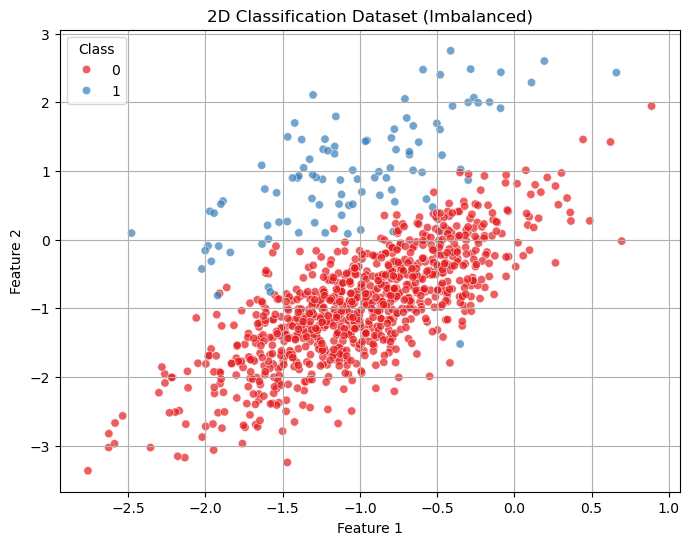

In [224]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x="feature1", y="feature2", hue="label", palette="Set1", alpha=0.7)
plt.title("2D Classification Dataset (Imbalanced)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend(title="Class")
plt.grid(True)
plt.show()

In [225]:
df["label"].value_counts()

label
0    900
1    100
Name: count, dtype: int64

In [226]:
!pip install imblearn

In [227]:
from imblearn.over_sampling import SMOTE

oversample = SMOTE()
X, y = oversample.fit_resample(df[["feature1","feature2"]], df["label"])
new_df = pd.DataFrame(X, columns=["feature1", "feature2"])
new_df["y"] = y
new_df.shape

(1800, 3)

In [228]:
new_df["y"].value_counts()

y
0    900
1    900
Name: count, dtype: int64

<Axes: xlabel='feature1', ylabel='feature2'>

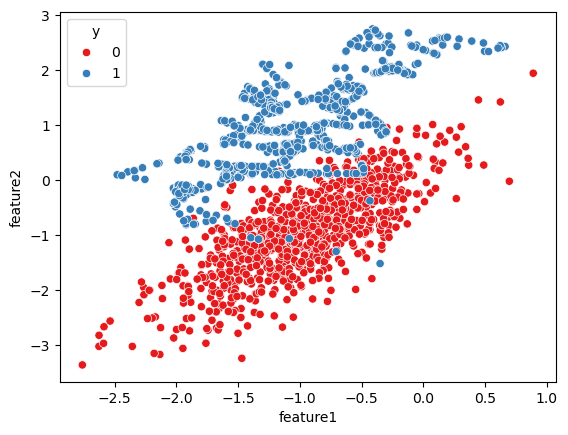

In [229]:
sns.scatterplot(data = new_df, x = "feature1", y="feature2", hue="y", palette="Set1")

In [230]:
import pandas as pd
import numpy as np

# Example data
data = [7, 15, 36, 39, 40, 41, 42, 43, 46, 49, 50, 60]

# Convert to DataFrame
df = pd.DataFrame(data, columns=["value"])

# 5-number summary
summary = {
    "Min": df["value"].min(),
    "Q1": df["value"].quantile(0.25),
    "Median (Q2)": df["value"].median(),
    "Q3": df["value"].quantile(0.75),
    "Max": df["value"].max()
}

print(summary)


{'Min': 7, 'Q1': 38.25, 'Median (Q2)': 41.5, 'Q3': 46.75, 'Max': 60}


In [231]:
minimum, Q1, median, Q3, maximum = np.quantile(data, [0,0.25,0.50,0.75,1])
minimum, Q1, median, Q3, maximum 

(7.0, 38.25, 41.5, 46.75, 60.0)

In [232]:
df.describe()

,value
count,12.000000
mean,39.000000
std,14.616305
min,7.000000
25%,38.250000
50%,41.500000
75%,46.750000
max,60.000000


In [233]:
IQR = Q3 - Q1
lower_fence = Q1 - 1.5 * (IQR)
upper_fence = Q3 + 1.5 * (IQR)
lower_fence, upper_fence

(25.5, 59.5)

In [234]:
for item in data:
    if item > upper_fence or item < lower_fence:
        print(item)

7
15
60


<Axes: >

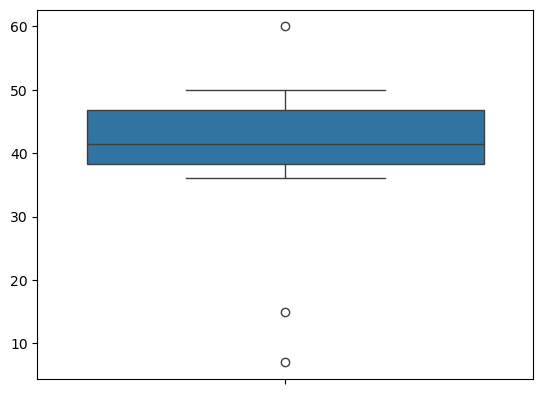

In [235]:
sns.boxplot(data)

In [236]:
### ENcoding

In [237]:
# OHE

import pandas as pd
from sklearn.preprocessing import OneHotEncoder

# Create Dataframe
df = pd.DataFrame({
    "color" : ["red", "green", "blue", "green", "red", "green", "blue"]
})
# df.head()

# create an instance of OHE
encoder = OneHotEncoder()
# firts fit and transform
encoded_color = encoder.fit_transform(df[["color"]]).toarray()
# create new dataframe
encode_df = pd.DataFrame(encoded_color, columns=encoder.get_feature_names_out())
encode_df.head()

,color_blue,color_green,color_red
0,0.0,0.0,1.0
1,0.0,1.0,0.0
2,1.0,0.0,0.0
3,0.0,1.0,0.0
4,0.0,0.0,1.0


In [238]:
pd.concat([df, encode_df], axis=1)

,color,color_blue,color_green,color_red
0,red,0.0,0.0,1.0
1,green,0.0,1.0,0.0
2,blue,1.0,0.0,0.0
3,green,0.0,1.0,0.0
4,red,0.0,0.0,1.0
5,green,0.0,1.0,0.0
6,blue,1.0,0.0,0.0


In [239]:
import seaborn as sns
tips_df = sns.load_dataset("tips")
tips_df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [240]:
tips_df[["sex"]].value_counts()

sex   
Male      157
Female     87
Name: count, dtype: int64

In [241]:
from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder()
ohe_sex = ohe.fit_transform(tips_df[["sex"]]).toarray()
ohe_sex_df = pd.DataFrame(ohe_sex, columns=ohe.get_feature_names_out())
# ohe_sex_df.head()
pd.concat([tips_df, ohe_sex_df], axis=1)

,total_bill,tip,sex,smoker,day,time,size,sex_Female,sex_Male
0,16.99,1.01,Female,No,Sun,Dinner,2,1.0,0.0
1,10.34,1.66,Male,No,Sun,Dinner,3,0.0,1.0
2,21.01,3.50,Male,No,Sun,Dinner,3,0.0,1.0
3,23.68,3.31,Male,No,Sun,Dinner,2,0.0,1.0
4,24.59,3.61,Female,No,Sun,Dinner,4,1.0,0.0
...,...,...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3,0.0,1.0
240,27.18,2.00,Female,Yes,Sat,Dinner,2,1.0,0.0
241,22.67,2.00,Male,Yes,Sat,Dinner,2,0.0,1.0
242,17.82,1.75,Male,No,Sat,Dinner,2,0.0,1.0


In [242]:
from sklearn.preprocessing import LabelEncoder
import pandas as pd

# Assume tips_df exists and has a 'sex' column
le = LabelEncoder()
le_sex = le.fit_transform(tips_df[["day"]])  # must be 1D

df_le_sex = pd.DataFrame(le_sex, columns=["day_encoded"])
# df_le_sex.head()
pd.concat([tips_df, df_le_sex],axis=1)

c:\Users\sande\anaconda3\Lib\site-packages\sklearn\preprocessing\_label.py:114: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,total_bill,tip,sex,smoker,day,time,size,day_encoded
0,16.99,1.01,Female,No,Sun,Dinner,2,2
1,10.34,1.66,Male,No,Sun,Dinner,3,2
2,21.01,3.50,Male,No,Sun,Dinner,3,2
3,23.68,3.31,Male,No,Sun,Dinner,2,2
4,24.59,3.61,Female,No,Sun,Dinner,4,2
...,...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3,1
240,27.18,2.00,Female,Yes,Sat,Dinner,2,1
241,22.67,2.00,Male,Yes,Sat,Dinner,2,1
242,17.82,1.75,Male,No,Sat,Dinner,2,1


In [243]:
import pandas as pd

# Sample dataset
df = pd.DataFrame({
    'city': ['Delhi', 'Mumbai', 'Chennai', 'Delhi', 'Mumbai', 'Chennai', 'Delhi'],
    'sales': [200, 300, 100, 250, 280, 130, 210]
})

# df.head()

sales_mean = df.groupby("city")['sales'].mean().to_dict()
print(sales_mean)
df["city_encode"] = df["city"].map(sales_mean)


{'Chennai': 115.0, 'Delhi': 220.0, 'Mumbai': 290.0}


## Red Wine Datasets

In [244]:
red_wine_df = pd.read_csv("winequality-red.csv", sep=";")
red_wine_df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [ ]:
# red_wine_df.info()
# red_wine_df.describe()
# red_wine_df.isnull().sum()
# red_wine_df.shape
# red_wine_df.columns

In [ ]:
# red_wine_df["quality"].value_counts()
# red_wine_df["quality"].unique()

In [247]:
# # missing values
# red_wine_df.isnull().sum()

In [ ]:
# red_wine_df.duplicated().sum()
# red_wine_df[red_wine_df.duplicated()]
# red_wine_df.drop_duplicates(inplace=True)

In [255]:
red_wine_df.corr()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
fixed acidity,1.000000,-0.255124,0.667437,0.111025,0.085886,-0.140580,-0.103777,0.670195,-0.686685,0.190269,-0.061596,0.119024
volatile acidity,-0.255124,1.000000,-0.551248,-0.002449,0.055154,-0.020945,0.071701,0.023943,0.247111,-0.256948,-0.197812,-0.395214
citric acid,0.667437,-0.551248,1.000000,0.143892,0.210195,-0.048004,0.047358,0.357962,-0.550310,0.326062,0.105108,0.228057
residual sugar,0.111025,-0.002449,0.143892,1.000000,0.026656,0.160527,0.201038,0.324522,-0.083143,-0.011837,0.063281,0.013640
chlorides,0.085886,0.055154,0.210195,0.026656,1.000000,0.000749,0.045773,0.193592,-0.270893,0.394557,-0.223824,-0.130988
free sulfur dioxide,-0.140580,-0.020945,-0.048004,0.160527,0.000749,1.000000,0.667246,-0.018071,0.056631,0.054126,-0.080125,-0.050463
total sulfur dioxide,-0.103777,0.071701,0.047358,0.201038,0.045773,0.667246,1.000000,0.078141,-0.079257,0.035291,-0.217829,-0.177855
density,0.670195,0.023943,0.357962,0.324522,0.193592,-0.018071,0.078141,1.000000,-0.355617,0.146036,-0.504995,-0.184252
pH,-0.686685,0.247111,-0.550310,-0.083143,-0.270893,0.056631,-0.079257,-0.355617,1.000000,-0.214134,0.213418,-0.055245
sulphates,0.190269,-0.256948,0.326062,-0.011837,0.394557,0.054126,0.035291,0.146036,-0.214134,1.000000,0.091621,0.248835


<Axes: >

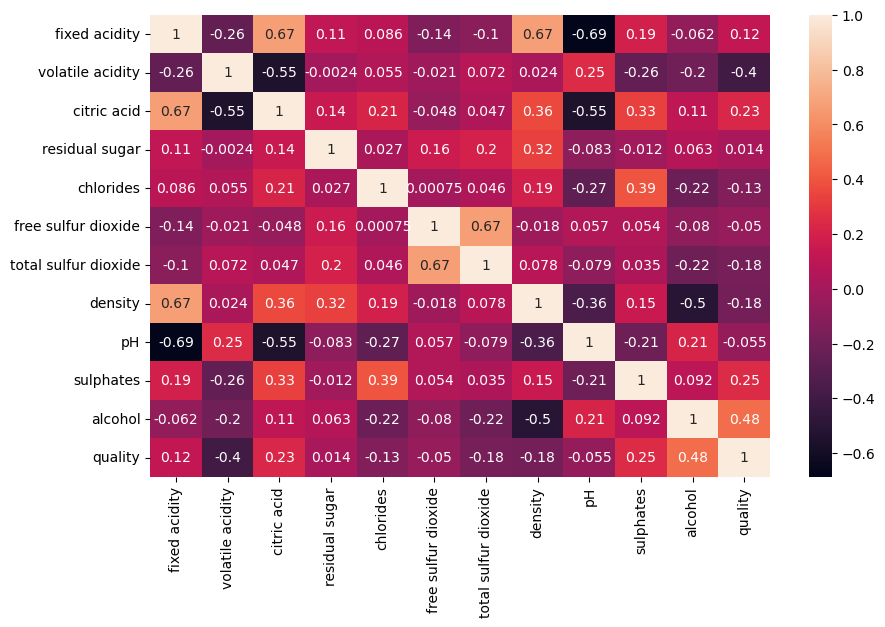

In [258]:
import seaborn as sns

plt.figure(figsize=(10,6))
sns.heatmap(red_wine_df.corr(), annot=True)

In [262]:
# sns.pairplot(red_wine_df)

<Axes: xlabel='quality', ylabel='count'>

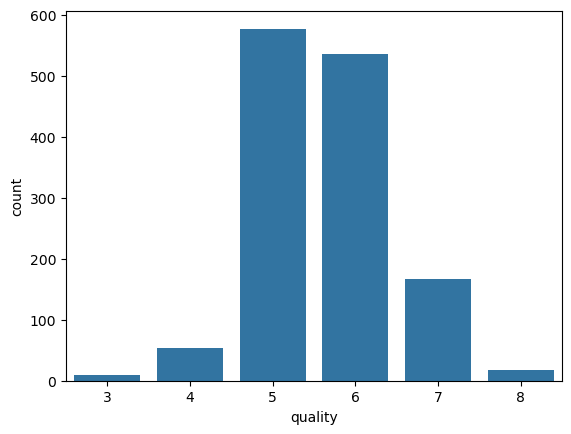

In [275]:
df = pd.DataFrame(red_wine_df["quality"].value_counts().reset_index(), columns=["quality", "count"])
sns.barplot(df, x = "quality", y = "count")

In [276]:
red_wine_df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
5,7.4,0.66,0.00,1.8,0.075,13.0,40.0,0.9978,3.51,0.56,9.4,5


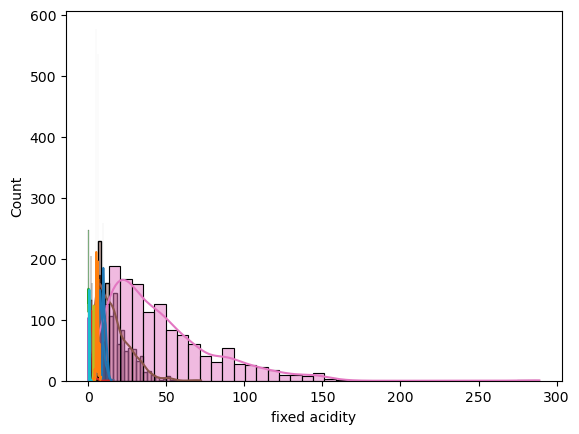

In [278]:
for column in red_wine_df.columns:
    sns.histplot(red_wine_df[column], kde=True)

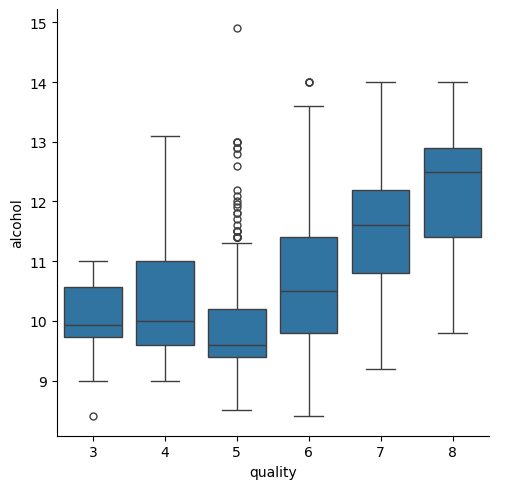

In [280]:
sns.catplot(data=red_wine_df, x="quality", y="alcohol", kind="box")

<Axes: xlabel='alcohol', ylabel='pH'>

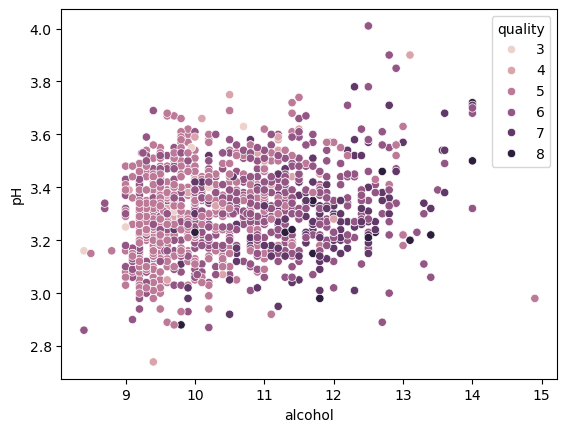

In [284]:
sns.scatterplot(x="alcohol", y="pH", hue="quality", data=red_wine_df)

## Flight Price Datasets

In [290]:
flight_df = pd.read_csv("./flight/economy.csv")
flight_df.head()

,date,airline,ch_code,num_code,dep_time,from,time_taken,stop,arr_time,to,price
0,11-02-2022,SpiceJet,SG,8709,18:55,Delhi,02h 10m,non-stop,21:05,Mumbai,"5,953"
1,11-02-2022,SpiceJet,SG,8157,06:20,Delhi,02h 20m,non-stop,08:40,Mumbai,"5,953"
2,11-02-2022,AirAsia,I5,764,04:25,Delhi,02h 10m,non-stop,06:35,Mumbai,"5,956"
3,11-02-2022,Vistara,UK,995,10:20,Delhi,02h 15m,non-stop,12:35,Mumbai,"5,955"
4,11-02-2022,Vistara,UK,963,08:50,Delhi,02h 20m,non-stop,11:10,Mumbai,"5,955"


In [291]:
# flight_df.isnull().sum(), flight_df.isna().sum()
# flight_df.duplicated().sum()
# print(flight_df.shape)
# flight_df.drop_duplicates(inplace=True)
# print(flight_df.shape)


In [300]:
new_flight_df = pd.DataFrame()
new_flight_df

""


#### EDA on Date and Airlines

In [ ]:
new_flight_df["full_date"] = flight_df["date"]
new_flight_df["date"] = flight_df["date"].str.split("-").str[0]
new_flight_df["month"] = flight_df["date"].str.split("-").str[1]
new_flight_df["year"] = flight_df["date"].str.split("-").str[2]

In [313]:
# from sklearn.preprocessing import OneHotEncoder

# ohe_airline = OneHotEncoder()
# airline_encode = ohe_airline.fit_transform(flight_df[["airline"]]).toarray()
# temp_df = pd.DataFrame(airline_encode, columns = ohe_airline.get_feature_names_out())
# temp_df.head()

from sklearn.preprocessing import LabelEncoder

le_airline = LabelEncoder()
airline_encode = le_airline.fit_transform(flight_df[["airline"]])
temp_df = pd.DataFrame(airline_encode, columns = ["airlline_encoder"])
temp_df["airline"] = flight_df[["airline"]]
new_flight_df = pd.concat([new_flight_df, temp_df], axis=1)


c:\Users\sande\anaconda3\Lib\site-packages\sklearn\preprocessing\_label.py:114: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [314]:
new_flight_df.head()

,full_date,date,month,year,airlline_encoder,airline
0,11-02-2022,11,02,2022,4,SpiceJet
1,11-02-2022,11,02,2022,4,SpiceJet
2,11-02-2022,11,02,2022,1,AirAsia
3,11-02-2022,11,02,2022,7,Vistara
4,11-02-2022,11,02,2022,7,Vistara


In [ ]:
new_flight_df["date"] = new_flight_df["date"].astype(int)
new_flight_df["month"] = new_flight_df["month"].astype(int)
new_flight_df["year"] = new_flight_df["year"].astype(int)
new_flight_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 206774 entries, 0 to 206773
Data columns (total 6 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   full_date         206774 non-null  object
 1   date              206774 non-null  int32 
 2   month             206774 non-null  int32 
 3   year              206774 non-null  int32 
 4   airlline_encoder  206774 non-null  int32 
 5   airline           206774 non-null  object
dtypes: int32(4), object(2)
memory usage: 6.3+ MB


In [321]:
new_flight_df.drop(columns=["full_date", "airline"], inplace=True)
new_flight_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 206774 entries, 0 to 206773
Data columns (total 4 columns):
 #   Column            Non-Null Count   Dtype
---  ------            --------------   -----
 0   date              206774 non-null  int32
 1   month             206774 non-null  int32
 2   year              206774 non-null  int32
 3   airlline_encoder  206774 non-null  int32
dtypes: int32(4)
memory usage: 3.2 MB


In [322]:
new_flight_df.head()

,date,month,year,airlline_encoder
0,11,2,2022,4
1,11,2,2022,4
2,11,2,2022,1
3,11,2,2022,7
4,11,2,2022,7


In [324]:
flight_df.head()

,date,airline,ch_code,num_code,dep_time,from,time_taken,stop,arr_time,to,price
0,11-02-2022,SpiceJet,SG,8709,18:55,Delhi,02h 10m,non-stop,21:05,Mumbai,"5,953"
1,11-02-2022,SpiceJet,SG,8157,06:20,Delhi,02h 20m,non-stop,08:40,Mumbai,"5,953"
2,11-02-2022,AirAsia,I5,764,04:25,Delhi,02h 10m,non-stop,06:35,Mumbai,"5,956"
3,11-02-2022,Vistara,UK,995,10:20,Delhi,02h 15m,non-stop,12:35,Mumbai,"5,955"
4,11-02-2022,Vistara,UK,963,08:50,Delhi,02h 20m,non-stop,11:10,Mumbai,"5,955"


In [339]:
new_flight_df["arrival_hrs"] = flight_df["arr_time"].str.split(":").str[0]
new_flight_df["arrival_min"] = flight_df["arr_time"].str.split(":").str[1]

new_flight_df["dept_hrs"] = flight_df["dep_time"].str.split(":").str[0]
new_flight_df["dept_min"] = flight_df["dep_time"].str.split(":").str[1]

In [340]:
# print(new_flight_df.info())
for col in list(new_flight_df.columns):
    new_flight_df[col] = new_flight_df[col].astype(int)
print(new_flight_df.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 206774 entries, 0 to 206773
Data columns (total 8 columns):
 #   Column            Non-Null Count   Dtype
---  ------            --------------   -----
 0   date              206774 non-null  int32
 1   month             206774 non-null  int32
 2   year              206774 non-null  int32
 3   airlline_encoder  206774 non-null  int32
 4   arrival_hrs       206774 non-null  int32
 5   arrival_min       206774 non-null  int32
 6   dept_hrs          206774 non-null  int32
 7   dept_min          206774 non-null  int32
dtypes: int32(8)
memory usage: 6.3 MB
None


In [341]:
flight_df["to"].unique()

array(['Mumbai', 'Bangalore', 'Kolkata', 'Hyderabad', 'Chennai', 'Delhi'],
      dtype=object)

In [344]:
flight_df.head()


,date,airline,ch_code,num_code,dep_time,from,time_taken,stop,arr_time,to,price
0,11-02-2022,SpiceJet,SG,8709,18:55,Delhi,02h 10m,non-stop,21:05,Mumbai,"5,953"
1,11-02-2022,SpiceJet,SG,8157,06:20,Delhi,02h 20m,non-stop,08:40,Mumbai,"5,953"
2,11-02-2022,AirAsia,I5,764,04:25,Delhi,02h 10m,non-stop,06:35,Mumbai,"5,956"
3,11-02-2022,Vistara,UK,995,10:20,Delhi,02h 15m,non-stop,12:35,Mumbai,"5,955"
4,11-02-2022,Vistara,UK,963,08:50,Delhi,02h 20m,non-stop,11:10,Mumbai,"5,955"


In [382]:
def time_to_hrs(time_str):
    split = time_str.split(" ")
    split[0] = split[0].strip().lower().replace("h", "")
    split[1] = split[1].replace("m", "")
    # print(split)
    hrs = float(split[0])
    if split[1] == "": split[1] = 0
    min_to_hrs = float(split[1]) / 60
    # print(split)
    return hrs + min_to_hrs


In [384]:
new_flight_df["time_taken_hrs"] = flight_df["time_taken"].apply(time_to_hrs)

In [387]:
new_flight_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 206774 entries, 0 to 206773
Data columns (total 9 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   date              206774 non-null  int32  
 1   month             206774 non-null  int32  
 2   year              206774 non-null  int32  
 3   airlline_encoder  206774 non-null  int32  
 4   arrival_hrs       206774 non-null  int32  
 5   arrival_min       206774 non-null  int32  
 6   dept_hrs          206774 non-null  int32  
 7   dept_min          206774 non-null  int32  
 8   time_taken_hrs    206774 non-null  float64
dtypes: float64(1), int32(8)
memory usage: 7.9 MB


In [403]:
def convert_stop(stop_str):
    stop = stop_str.split("-")[0].replace("+","")
    num_stop = 0
    if stop == "non": num_stop = 0
    else: num_stop = int(stop)
    return num_stop

In [404]:
new_flight_df["num_stops"] = flight_df["stop"].apply(convert_stop)

In [409]:
new_flight_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 206774 entries, 0 to 206773
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   date              206774 non-null  int32  
 1   month             206774 non-null  int32  
 2   year              206774 non-null  int32  
 3   airlline_encoder  206774 non-null  int32  
 4   arrival_hrs       206774 non-null  int32  
 5   arrival_min       206774 non-null  int32  
 6   dept_hrs          206774 non-null  int32  
 7   dept_min          206774 non-null  int32  
 8   time_taken_hrs    206774 non-null  float64
 9   num_stops         206774 non-null  int64  
dtypes: float64(1), int32(8), int64(1)
memory usage: 9.5 MB


In [413]:
flight_df.head()

,date,airline,ch_code,num_code,dep_time,from,time_taken,stop,arr_time,to,price
0,11-02-2022,SpiceJet,SG,8709,18:55,Delhi,02h 10m,non-stop,21:05,Mumbai,"5,953"
1,11-02-2022,SpiceJet,SG,8157,06:20,Delhi,02h 20m,non-stop,08:40,Mumbai,"5,953"
2,11-02-2022,AirAsia,I5,764,04:25,Delhi,02h 10m,non-stop,06:35,Mumbai,"5,956"
3,11-02-2022,Vistara,UK,995,10:20,Delhi,02h 15m,non-stop,12:35,Mumbai,"5,955"
4,11-02-2022,Vistara,UK,963,08:50,Delhi,02h 20m,non-stop,11:10,Mumbai,"5,955"


In [426]:
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder

le_to = LabelEncoder()
le_fron = LabelEncoder()
le_airline = LabelEncoder()
ohe_ch_code = OneHotEncoder()

ch_code_encode = ohe_ch_code.fit_transform(flight_df[["ch_code"]]).toarray()
temp_df_ch_code = pd.DataFrame(ch_code_encode, columns=ohe_ch_code.get_feature_names_out())

airline_encode = le_airline.fit_transform(flight_df[["airline"]])
temp_df_airline = pd.DataFrame(airline_encode, columns = ["airlline_encoder"])

encode_to = le_to.fit_transform(flight_df[["to"]])
temp_df_to = pd.DataFrame(encode_to, columns=["Encode_to"])

encode_from = le_fron.fit_transform(flight_df[["from"]])
temp_df_from = pd.DataFrame(encode_from, columns=["Encode_from"])

new_flight_df = pd.concat([new_flight_df, temp_df_from, temp_df_to, temp_df_airline, temp_df_ch_code], axis=1)

c:\Users\sande\anaconda3\Lib\site-packages\sklearn\preprocessing\_label.py:114: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\sande\anaconda3\Lib\site-packages\sklearn\preprocessing\_label.py:114: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\sande\anaconda3\Lib\site-packages\sklearn\preprocessing\_label.py:114: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [427]:
new_flight_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 206774 entries, 0 to 206773
Data columns (total 25 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   date              206774 non-null  int32  
 1   month             206774 non-null  int32  
 2   year              206774 non-null  int32  
 3   airlline_encoder  206774 non-null  int32  
 4   arrival_hrs       206774 non-null  int32  
 5   arrival_min       206774 non-null  int32  
 6   dept_hrs          206774 non-null  int32  
 7   dept_min          206774 non-null  int32  
 8   time_taken_hrs    206774 non-null  float64
 9   num_stops         206774 non-null  int64  
 10  Encode_from       206774 non-null  int32  
 11  Encode_to         206774 non-null  int32  
 12  airlline_encoder  206774 non-null  int32  
 13  num_code          206774 non-null  int64  
 14  Encode_from       206774 non-null  int32  
 15  Encode_to         206774 non-null  int32  
 16  airlline_encoder  20